# 01 · Le conditionnement, à la main : pourquoi il ne produit jamais de ventes négatives

**Bloc 6 · W37 — BayesReconPy, notebook 1 sur 2.**

Le bloc 4 a montré que réconcilier une distribution demande la **loi jointe**. MinT et ses variantes
gaussiennes ajoutent une seconde hypothèse : des distributions **continues et symétriques**. Sur des ventes à
rotation lente (beaucoup de zéros), cette hypothèse est fausse, et une prévision réconciliée peut devenir
négative.

BayesReconPy réconcilie autrement : par **conditionnement**. Ce notebook le fait à la main, sur un exemple
assez petit pour être calculé exactement, puis vérifie que la bibliothèque retrouve le même résultat.

| § | Contenu |
|---|---|
| 1 | Le problème : une gaussienne sur des ventes proches de zéro |
| 2 | L'exemple : 2 articles intermittents, 1 total, des prévisions incohérentes |
| 3 | Le conditionnement en une image |
| 4 | Le résultat exact, comparé au MinT gaussien |
| 5 | L'algorithme BUIS en dix lignes, et BayesReconPy |

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder ·
> 🔬 **Test d'hypothèse**, une hypothèse formulée, testée, puis acceptée ou rejetée.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

from w37_reconciliation import viz
from w37_reconciliation.bayesrecon.pmf import Normal, Pmf
from w37_reconciliation.bayesrecon.toy import Toy

viz.setup()
pd.set_option("display.precision", 3)
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")

## 1. Le problème : une gaussienne sur des ventes proches de zéro

Un article vend en moyenne 0,8 unité par jour (c'est la médiane des 3 049 articles du magasin M5 du
notebook 02), avec une loi binomiale négative choisie pour l'illustration. Ses ventes sont 0, 1, 2, 3… jamais
−1. Une prévision gaussienne de même moyenne et de même écart-type est pourtant ce que manipule MinT.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


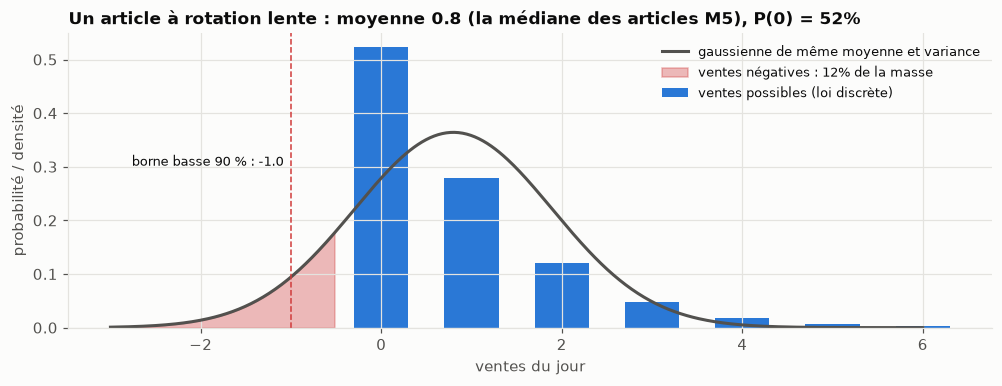

In [2]:
k = np.arange(0, 7)
nbinom = Pmf.of(stats.nbinom.pmf(np.arange(60), 1.6, 1.6 / (1.6 + 0.8)))      # moyenne 0,8, surdispersée
g = Normal(nbinom.mean, np.sqrt(nbinom.var))
x = np.linspace(-3, 6, 400)
fig, ax = plt.subplots(figsize=(9, 3.4), layout="constrained")
ax.bar(k, nbinom.p[:7], width=0.6, color=viz.BLUE, label="ventes possibles (loi discrète)")
ax.plot(x, stats.norm.pdf(x, g.mu, g.sd), color=viz.TEXT_2, lw=2, label="gaussienne de même moyenne et variance")
neg = x[x < -0.5]
ax.fill_between(neg, stats.norm.pdf(neg, g.mu, g.sd), color=viz.CRITICAL, alpha=0.35,
                label=f"ventes négatives : {g.prob_negative():.0%} de la masse")
ax.axvline(g.quantile(0.05), color=viz.CRITICAL, ls="--", lw=1)
ax.text(g.quantile(0.05) - 0.08, ax.get_ylim()[1] * 0.55, f"borne basse 90 % : {g.quantile(0.05):.1f}",
        fontsize=8.5, ha="right")
ax.set_xlabel("ventes du jour"); ax.set_ylabel("probabilité / densité")
ax.legend(fontsize=8.5, loc="upper right")
ax.set_title(f"Un article à rotation lente : moyenne {nbinom.mean:.1f} (la médiane des articles M5), "
             f"P(0) = {nbinom.p[0]:.0%}")
export(fig, "gaussienne_sur_comptage"); plt.show()

💡 **Le problème n'est pas la moyenne, c'est la forme.** Une loi de comptage proche de zéro est **asymétrique** :
une masse au pied du mur (zéro), une queue vers la droite. Une gaussienne est symétrique : pour avoir la bonne
variance, elle doit déborder à gauche de zéro. L'intervalle de prévision à 90 % commence alors en dessous de
zéro, ce qui, pour un approvisionneur, ne veut rien dire.

⚠️ **Point d'attention.** Ce problème existe **avant** toute réconciliation. MinT l'aggrave (§ 4) : en corrigeant
les moyennes, il peut en pousser certaines elles-mêmes sous zéro.

## 2. L'exemple : deux articles intermittents, un total

| série | prévision de base | moyenne |
|---|---|---|
| article 1 | Poisson(λ₁ = 0,4) | 0,4 |
| article 2 | Poisson(λ₂ = 0,8) | 0,8 |
| total | gaussienne N(0,6 ; 0,5²) | 0,6 |

Les prévisions sont **incohérentes** : la somme des moyennes des articles vaut 1,2, le total en prévoit 0,6.
Le total a été prévu par un autre modèle, sur une série plus lisse ; il « sait » quelque chose que les articles
ne savent pas, par exemple qu'une promotion est finie.

In [3]:
toy = Toy()
base = toy.base()
print(f"somme des moyennes des articles : {base['b1'].mean + base['b2'].mean:.2f} ; moyenne du total : {base['total'].mean:.2f}")

somme des moyennes des articles : 1.20 ; moyenne du total : 0.60


## 3. Le conditionnement en une image

L'idée tient en une phrase : **on garde la loi jointe des articles, et on la repondère par ce que dit le total**.

1. **Base** : la probabilité de chaque couple de ventes (b₁, b₂), si les articles sont indépendants.
2. **Vraisemblance** : ce que la prévision du total pense de leur somme b₁ + b₂. Elle est constante le long des
   diagonales b₁ + b₂ = s.
3. **Réconcilié** : le produit des deux, renormalisé. C'est la règle de Bayes.

Tout reste sur la grille des entiers positifs : aucune case négative n'existe, donc aucune ne peut recevoir de
probabilité.

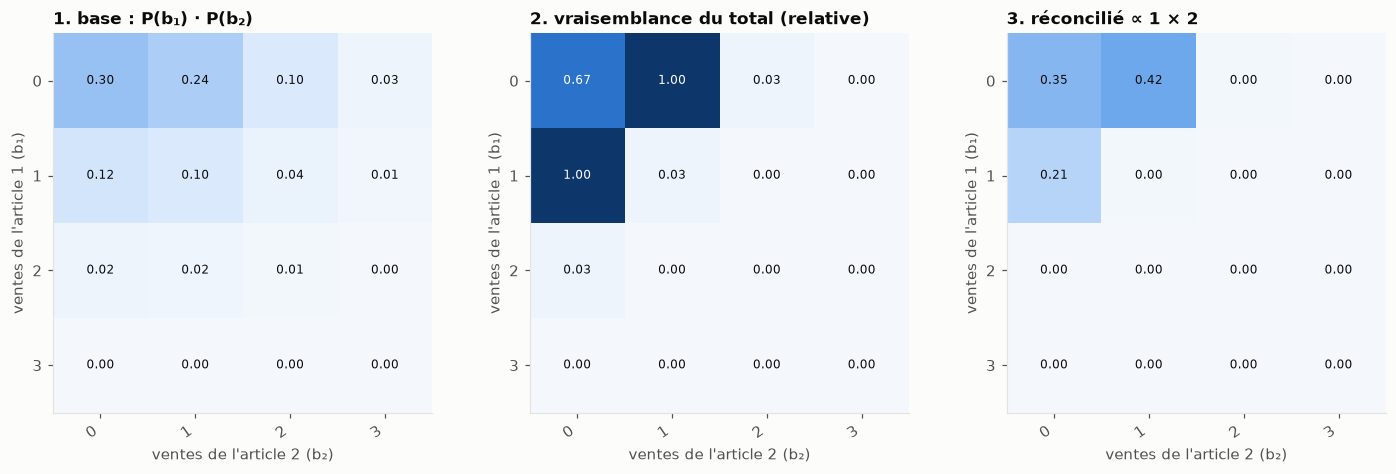

In [4]:
K = 4
kk = np.arange(K)
base_joint = stats.poisson.pmf(kk, toy.lam1)[:, None] * stats.poisson.pmf(kk, toy.lam2)[None, :]
lik = stats.norm.pdf(kk[:, None] + kk[None, :], toy.mu_total, toy.sd_total)
rec = base_joint * lik; rec /= rec.sum()
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), layout="constrained")
for ax, M, title in zip(axes, [base_joint / base_joint.sum(), lik / lik.max(), rec],
                        ["1. base : P(b₁) · P(b₂)", "2. vraisemblance du total (relative)", "3. réconcilié ∝ 1 × 2"]):
    viz.heatmap(ax, M, [str(i) for i in kk], [str(i) for i in kk], fmt="{:.2f}", vmax=1, colorbar=False, title=title)
    ax.set_xlabel("ventes de l'article 2 (b₂)"); ax.set_ylabel("ventes de l'article 1 (b₁)")
export(fig, "conditionnement_grille"); plt.show()

**Lecture.** Le total, centré sur 0,6, trouve une somme de 2 peu plausible : après repondération, la case (1, 1)
perd presque tout son poids, au profit de (0, 0), (1, 0) et (0, 1), dont la somme est proche de 0,6.
Les articles sont **ajustés ensemble**, de façon cohérente avec le total, et sans jamais quitter les entiers.

## 4. Le résultat exact, comparé au MinT gaussien

Le MinT gaussien remplace chaque Poisson par une gaussienne de même moyenne et variance, puis projette
(formule MinT, W diagonale). On compare les deux résultats, série par série.

,"base, moyenne","conditionnement, moyenne","MinT gaussien, moyenne","conditionnement, P(vente < 0)","MinT gaussien, P(vente < 0)","MinT gaussien, borne basse 90 %"
article 1,0.4,0.219,0.234,0.0,0.086,-0.651
article 2,0.8,0.437,0.469,0.0,0.053,-0.516
total,0.6,0.656,0.703,0.0,0.004,-0.045


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


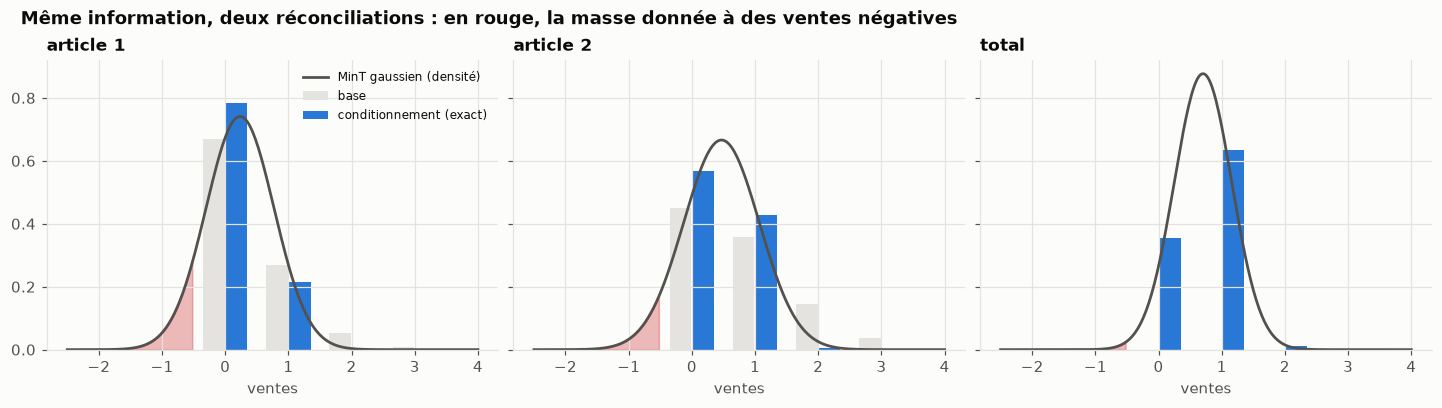

In [5]:
exact, mint = toy.exact(), toy.gaussian_mint()
rows = {}
for s in ("b1", "b2", "total"):
    rows[s] = {"base, moyenne": base[s].mean, "conditionnement, moyenne": exact[s].mean,
               "MinT gaussien, moyenne": mint[s].mean,
               "conditionnement, P(vente < 0)": 0.0, "MinT gaussien, P(vente < 0)": mint[s].prob_negative(),
               "MinT gaussien, borne basse 90 %": mint[s].quantile(0.05)}
display(pd.DataFrame(rows).T.rename(index={"b1": "article 1", "b2": "article 2"}))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained", sharey=True)
x = np.linspace(-2.5, 4, 300)
for ax, s, title in zip(axes, ("b1", "b2", "total"), ("article 1", "article 2", "total")):
    ax.bar(np.arange(4) - 0.18, base[s].p[:4] if isinstance(base[s], Pmf) else np.zeros(4), width=0.34,
           color=viz.GRID, label="base")
    ax.bar(np.arange(4) + 0.18, exact[s].p[:4], width=0.34, color=viz.BLUE, label="conditionnement (exact)")
    d = mint[s]
    ax.plot(x, stats.norm.pdf(x, d.mu, d.sd), color=viz.TEXT_2, lw=1.8, label="MinT gaussien (densité)")
    ax.fill_between(x[x < -0.5], stats.norm.pdf(x[x < -0.5], d.mu, d.sd), color=viz.CRITICAL, alpha=0.35)
    ax.set_title(title); ax.set_xlabel("ventes")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Même information, deux réconciliations : en rouge, la masse donnée à des ventes négatives",
             x=0.01, ha="left", fontweight="semibold")
export(fig, "conditionnement_vs_mint"); plt.show()

**Lecture.**

- Les deux méthodes **baissent les articles** pour les rapprocher du total, et sont **cohérentes** (les moyennes
  des articles somment à celle du total).
- Le conditionnement le fait **sur les entiers** : P(vente < 0) = 0, par construction.
- Le MinT gaussien donne **plusieurs pourcents** de probabilité à des ventes négatives sur chaque article, et
  ses intervalles à 90 % commencent sous zéro.
- Les moyennes ne sont pas identiques : la gaussienne et la Poisson n'ont pas la même forme, la règle de
  Bayes ne donne donc pas le même compromis.

📌 **À retenir.** MinT **projette** des moyennes et des covariances ; le conditionnement **repondère** une loi
jointe. Le premier vit dans ℝ, le second sur le support des données. Pour des comptages proches de zéro, c'est
toute la différence.

## 5. L'algorithme BUIS en dix lignes, puis BayesReconPy

Sur 2 articles, on peut énumérer toutes les cases de la grille. Sur 3 049, non. BayesReconPy procède par
**échantillonnage d'importance** (*Bottom-Up Importance Sampling*, BUIS) :

1. tirer des articles selon leur loi de base ;
2. donner à chaque tirage un poids : la densité de la prévision du total en leur somme ;
3. rééchantillonner selon ces poids.

C'est exactement le § 3, mais avec des tirages au lieu d'une grille. Le code est dans
`Toy.buis_by_hand` ; on compare les trois résultats.

In [6]:
hand, lib = toy.buis_by_hand(), toy.buis()
cmp = pd.DataFrame({f"{src} · P({k})": [d[s].p[k] if k < len(d[s].p) else 0.0 for s in ("b1", "b2", "total")]
                    for src, d in [("exact", exact), ("à la main", hand), ("BayesReconPy", lib)] for k in (0, 1, 2)},
                   index=["article 1", "article 2", "total"])
display(cmp.T)
err = max(abs(lib[s].p[k] - exact[s].p[k]) for s in ("b1", "b2", "total") for k in range(3))
print(f"écart maximal BayesReconPy / exact : {err:.4f} (200 000 tirages ; erreur Monte-Carlo attendue ≈ 0,001)")

,article 1,article 2,total
exact · P(0),0.783,0.567,0.355
exact · P(1),0.216,0.428,0.635
exact · P(2),0.001,0.005,0.010
à la main · P(0),0.781,0.566,0.352
à la main · P(1),0.218,0.429,0.638
à la main · P(2),0.001,0.005,0.011
BayesReconPy · P(0),0.784,0.567,0.355
BayesReconPy · P(1),0.215,0.428,0.635
BayesReconPy · P(2),0.001,0.004,0.010


écart maximal BayesReconPy / exact : 0.0010 (200 000 tirages ; erreur Monte-Carlo attendue ≈ 0,001)


**Conclusion.** BayesReconPy et la version à la main retrouvent la loi exacte, au bruit d'échantillonnage près
(test `test_bayesreconpy_buis_recovers_the_exact_conditional_distribution`). La bibliothèque fait ce qu'elle
annonce, sur un cas où l'on connaît la réponse.

⚠️ **Point d'attention — la limite de BUIS en grande dimension.** Avec 3 049 articles, la plupart des tirages
indépendants donnent une somme loin du total prévu : leurs poids sont quasi nuls, et quelques tirages
concentrent tout le poids. La **taille d'échantillon effective** (ESS) s'effondre. C'est pourquoi
BayesReconPy propose **TD-cond** (*top-down conditioning*), qui réconcilie d'abord les agrégats, puis descend vers
les articles. Le notebook 02 les compare sur le magasin M5.

📌 **À retenir — le conditionnement.**
- Réconcilier par conditionnement = **garder la loi jointe des articles et la repondérer** par la prévision des
  agrégats (règle de Bayes).
- Le résultat reste sur le **support des données** : pas de vente négative, pas de demi-article.
- Sur un exemple calculable à la main, **BayesReconPy retrouve la solution exacte**.
- En grande dimension, l'échantillonnage d'importance perd en efficacité : d'où TD-cond.